In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

In [71]:
df = pd.read_csv(r"C:\allcoding\creditcard.csv")

In [72]:
print(type(df))

<class 'pandas.DataFrame'>


In [73]:
df.shape      #The dataset contains 284,807 transactions and 31 attributes including the target variable Class.

(284807, 31)

In [74]:
df.info      #All columns are numerical and no missing values are present in the dataset.

<bound method DataFrame.info of             Time         V1         V2        V3        V4        V5  \
0            0.0  -1.359807  -0.072781  2.536347  1.378155 -0.338321   
1            0.0   1.191857   0.266151  0.166480  0.448154  0.060018   
2            1.0  -1.358354  -1.340163  1.773209  0.379780 -0.503198   
3            1.0  -0.966272  -0.185226  1.792993 -0.863291 -0.010309   
4            2.0  -1.158233   0.877737  1.548718  0.403034 -0.407193   
...          ...        ...        ...       ...       ...       ...   
284802  172786.0 -11.881118  10.071785 -9.834783 -2.066656 -5.364473   
284803  172787.0  -0.732789  -0.055080  2.035030 -0.738589  0.868229   
284804  172788.0   1.919565  -0.301254 -3.249640 -0.557828  2.630515   
284805  172788.0  -0.240440   0.530483  0.702510  0.689799 -0.377961   
284806  172792.0  -0.533413  -0.189733  0.703337 -0.506271 -0.012546   

              V6        V7        V8        V9  ...       V21       V22  \
0       0.462388  0.239599  

In [75]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [76]:
df["Class"].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [77]:
df["Class"].value_counts(normalize=True) * 100

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64

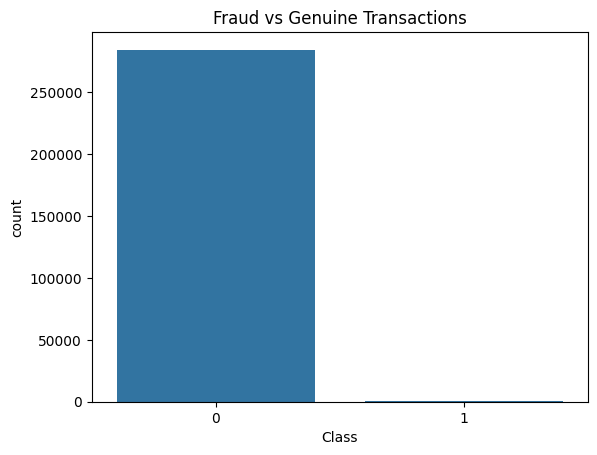

In [78]:
# Visualize Class Distribution
sns.countplot(x="Class",data =df)
plt.title("Fraud vs Genuine Transactions")
plt.show()

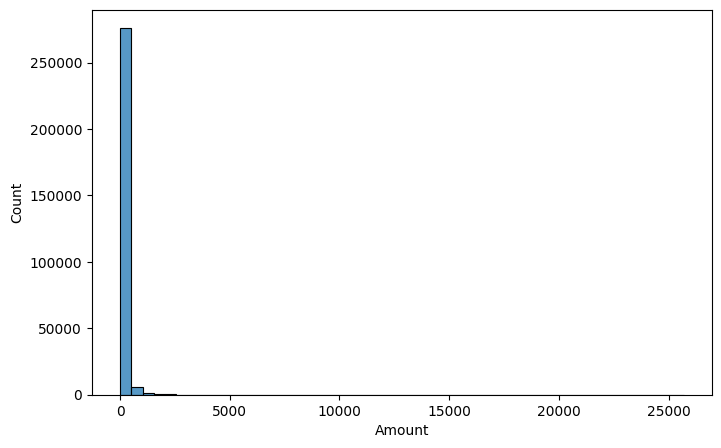

In [79]:
#Distribution of Amount
plt.figure(figsize=(8,5))       
sns.histplot(df["Amount"],bins=50)
plt.show()

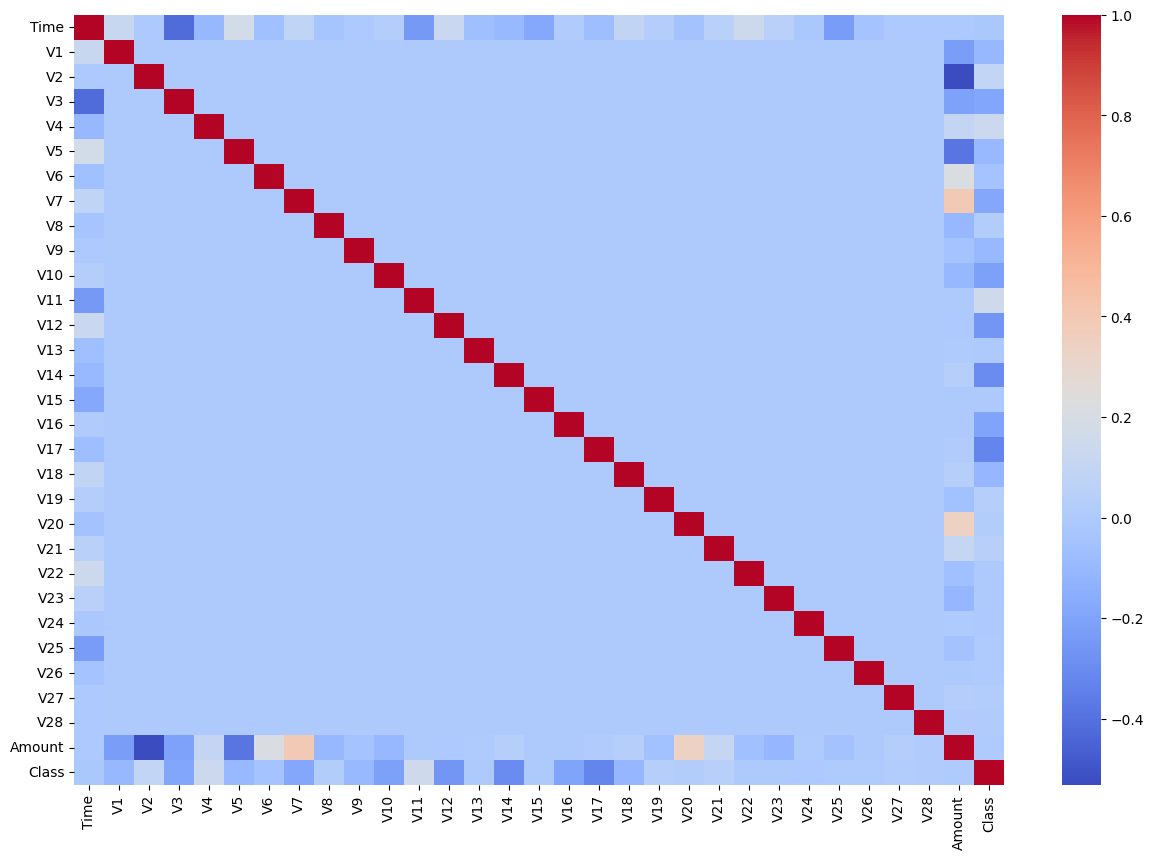

In [80]:
#Correlation Heatmap
plt.figure (figsize=(15,10))
sns.heatmap(df.corr(),cmap="coolwarm")
plt.show()

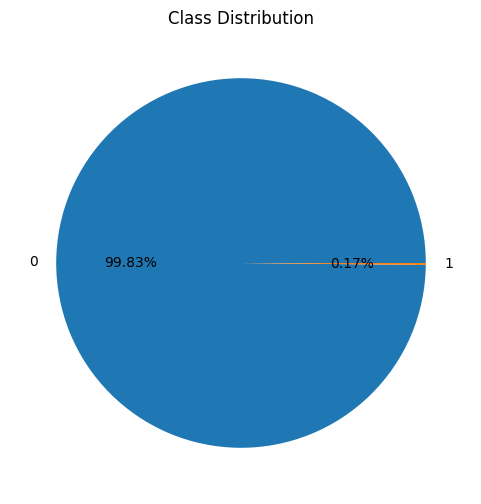

In [81]:
 # Pie Chart 
plt.figure(figsize=(6,6))

df["Class"].value_counts().plot(
    kind="pie",
    autopct="%1.2f%%"
)

plt.ylabel("")
plt.title("Class Distribution")

plt.show()

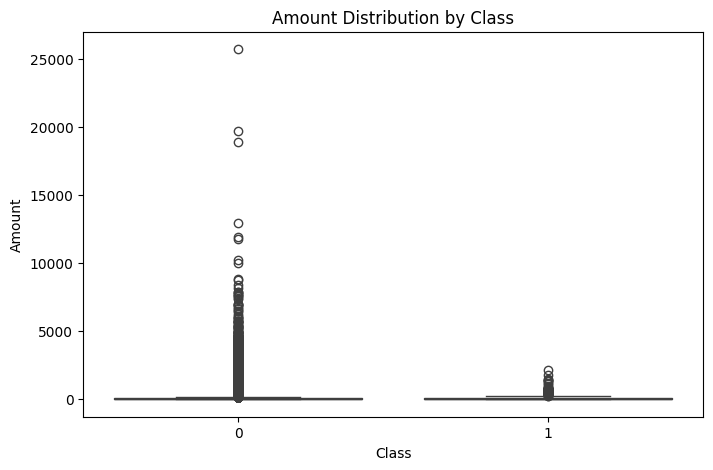

In [82]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Class", y="Amount", data=df)
plt.title("Amount Distribution by Class")
plt.show()


In [83]:
#Features Correlated With Fraud
corr = df.corr()["Class"].sort_values()

print("Most Negative Correlations:")
print(corr.head(10))

print("\nMost Positive Correlations:")
print(corr.tail(10))

Most Negative Correlations:
V17   -0.326481
V14   -0.302544
V12   -0.260593
V10   -0.216883
V16   -0.196539
V3    -0.192961
V7    -0.187257
V18   -0.111485
V1    -0.101347
V9    -0.097733
Name: Class, dtype: float64

Most Positive Correlations:
V28      0.009536
V27      0.017580
V8       0.019875
V20      0.020090
V19      0.034783
V21      0.040413
V2       0.091289
V4       0.133447
V11      0.154876
Class    1.000000
Name: Class, dtype: float64


In [84]:
# DATA PREPERATION
X=df.drop("Class",axis=1)
y=df["Class"]

In [85]:
# TRAIN _ TEST split
X_train , X_test , y_train , y_test =train_test_split(
    X,y,test_size=0.2,random_state=42,
    stratify=y
)
print(X_train.shape)
print(X_test.shape)


(227845, 30)
(56962, 30)


In [86]:
# Import SMOTE to training data  
from imblearn.over_sampling import SMOTE


In [87]:
#apply smote
smote= SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)
print(y_train.value_counts())
print(y_train_smote.value_counts())

Class
0    227451
1       394
Name: count, dtype: int64
Class
0    227451
1    227451
Name: count, dtype: int64


In [88]:
# Logistic Regression
from sklearn.preprocessing import StandardScaler
scaler= StandardScaler()
X_train_scaled= scaler.fit_transform(
    X_train_smote
)
X_test_scaled=scaler.transform(
    X_test
)

In [89]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=1000
)

lr.fit(
    X_train_scaled,
    y_train_smote
)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [90]:
# PREDICTIONS
y_pred_lr = lr.predict(
    X_test_scaled
)

y_prob_lr = lr.predict_proba(
    X_test_scaled
)[:,1]

In [91]:
#Evaluation

from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix
)

print(
    classification_report(
        y_test,
        y_pred_lr
    )
)

print(
    roc_auc_score(
        y_test,
        y_prob_lr
    )
)

              precision    recall  f1-score   support

           0       1.00      0.99      0.99     56864
           1       0.13      0.90      0.23        98

    accuracy                           0.99     56962
   macro avg       0.57      0.94      0.61     56962
weighted avg       1.00      0.99      0.99     56962

0.9764816590676788


In [92]:
#Random Forest Model
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=50,
    random_state=42,
    n_jobs=-1
)

rf.fit(
    X_train_smote,
    y_train_smote
)
print("Training Complete")

Training Complete


In [93]:
#predictions
y_pred_rf = rf.predict(
    X_test
)

y_prob_rf = rf.predict_proba(
    X_test
)[:,1]

In [94]:
# Evaluation
print(
    classification_report(
        y_test,
        y_pred_rf
    )
)

print(
    roc_auc_score(
        y_test,
        y_prob_rf
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.83      0.83        98

    accuracy                           1.00     56962
   macro avg       0.91      0.91      0.91     56962
weighted avg       1.00      1.00      1.00     56962

0.960818167658172


In [95]:
#Hyperparameter Tuning
#Logistic Regression
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

param_grid_lr = {
    "C": [0.1, 1]
}

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid_lr,
    cv=3,
    scoring="roc_auc",
    n_jobs=-1
)

grid_lr.fit(
    X_train_scaled,
    y_train_smote
)

print("Best Parameters:", grid_lr.best_params_)

Best Parameters: {'C': 1}


In [96]:
#Random Forest
param_grid_rf = {
    "n_estimators":[50,100],
    "max_depth":[10,None]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ),
    param_grid_rf,
    cv=3,
    scoring="roc_auc"
)
grid_rf.fit(
    X_train_smote,
    y_train_smote
)

print(grid_rf.best_params_)
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

{'max_depth': None, 'n_estimators': 100}
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.83      0.83        98

    accuracy                           1.00     56962
   macro avg       0.91      0.91      0.91     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.960818167658172


In [98]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred_lr))
print(confusion_matrix(y_test, y_pred_rf))

[[56296   568]
 [   10    88]]
[[56847    17]
 [   17    81]]


In [99]:
print(classification_report(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lr))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99     56864
           1       0.13      0.90      0.23        98

    accuracy                           0.99     56962
   macro avg       0.57      0.94      0.61     56962
weighted avg       1.00      0.99      0.99     56962

ROC-AUC: 0.9764816590676788


# Model Comparison

A fraud detection system was developed using **Logistic Regression** and **Random Forest** classifiers on the Credit Card Fraud Detection dataset. Exploratory Data Analysis (EDA) revealed a severe class imbalance, with fraudulent transactions accounting for only **0.17%** of the dataset. To address this issue, **SMOTE (Synthetic Minority Oversampling Technique)** was applied to the training data.

Both models were evaluated using **Precision, Recall, F1-Score, and ROC-AUC** metrics. Logistic Regression achieved a **ROC-AUC score of 0.9765** and a **recall of 0.90**, indicating a strong capability to identify fraudulent transactions. However, its **precision was only 0.13**, resulting in a large number of false positive predictions.

Random Forest achieved a **ROC-AUC score of 0.9608** with both **precision and recall equal to 0.83**. Although its ROC-AUC score was slightly lower than that of Logistic Regression, it produced significantly fewer false positives while maintaining strong fraud detection performance.

Therefore, **Random Forest was selected as the final model** because it provided the best balance between fraud detection capability and false alarm reduction. The results demonstrate the importance of handling class imbalance and selecting appropriate evaluation metrics when building effective fraud detection systems.


# Credit Card Fraud Detection Using Machine Learning

## 1. Import Libraries

## 2. Load Dataset

## 3. Exploratory Data Analysis (EDA)

### 3.1 Dataset Shape

### 3.2 Missing Values

### 3.3 Class Distribution

### 3.4 Amount Distribution

### 3.5 Correlation Analysis

## 4. Data Preprocessing

### 4.1 Train-Test Split

### 4.2 SMOTE

## 5. Logistic Regression

## 6. Random Forest

## 7. Hyperparameter Tuning

## 8. Model Comparison

## 9. Conclusion

# Conclusion

This project developed a machine learning-based fraud detection system using the Credit Card Fraud Detection dataset. Exploratory Data Analysis (EDA) showed that the dataset was highly imbalanced, with fraudulent transactions representing only a very small percentage of all transactions. To address this issue, the SMOTE (Synthetic Minority Oversampling Technique) method was applied to the training data.

Two classification models, Logistic Regression and Random Forest, were trained and evaluated using Precision, Recall, F1-Score, and ROC-AUC metrics. Logistic Regression achieved a high recall of 0.90 and a ROC-AUC score of 0.9765, indicating strong capability in identifying fraudulent transactions. However, it produced a large number of false positive predictions, resulting in low precision.

Random Forest achieved a ROC-AUC score of 0.9608 with a precision of 0.83 and recall of 0.83. Although its recall was slightly lower than Logistic Regression, it provided a much better balance between identifying fraud cases and minimizing false alarms.

Based on the overall performance comparison, Random Forest was selected as the final model for fraud detection because it demonstrated strong predictive capability while maintaining high precision and reducing false positive predictions. This project highlights the importance of handling class imbalance and using appropriate evaluation metrics when developing fraud detection systems.